# King County Flood Infrastructure Exposure — March 17–21, 2026

An analysis of which roads and buildings fell within the flood extent of the
March 17–21, 2026 King County atmospheric-river flood event, using free
Sentinel-1/Sentinel-2 satellite imagery and real King County GIS data.

**Source:** [King County Flood Control District event report](https://kingcountyfloodcontrol.org/march-17-21-2026-flood-event-report/)
— the Snoqualmie and Tolt Rivers both reached Phase 3 (the report's highest
alert level), twice, making the Snoqualmie Valley / Tolt River confluence
(Fall City–Carnation–Duvall) the most severely affected area in the county.

**Scope note — exposure, not visual damage.** No confirmed very-high-resolution
(sub-meter) imagery source was available for this specific event (no Maxar
Open Data Program activation found). At Sentinel's 10m resolution, a washed-out
road and a merely-flooded-but-intact road look identical. So this project
answers a narrower, honest question: **which specific named roads and
buildings fell inside the derived flood extent** — exposure, not a visual
damage classification.

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
from rasterio.vrt import WarpedVRT
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin
from rasterio.features import shapes
from scipy.ndimage import median_filter, binary_opening, binary_closing
from pystac_client import Client
import planetary_computer
import geoai
import matplotlib.pyplot as plt
import requests
import os

DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # macOS OpenMP conflict workaround, see Step 5

KC_GIS = "https://services.arcgis.com/Ej0PsM5Aw677QF1W/arcgis/rest/services"
DST_CRS = "EPSG:32610"  # UTM 10N
RES = 10.0  # Sentinel-1/2 native resolution

## Step 1: Define the real study area

Rather than approximate coordinates, the AOI is built from two real King
County GIS layers: the Snoqualmie/Tolt River centerlines (`STREAMTYPE_LINE`)
and the exact road segments the flood report names as affected
(`TRANS_NETWORK_CAR_LINE`) — buffered and unioned into one valley-corridor
polygon.

In [2]:
# Real Snoqualmie + Tolt River mainstem geometry (excludes upstream forks)
url = f"{KC_GIS}/STREAMTYPE_LINE_3013/FeatureServer/0/query"
resp = requests.get(url, params={
    "where": "WTR_NAME IN ('Snoqualmie River','Tolt River')",
    "outFields": "WTR_NAME", "outSR": 4326, "f": "geojson",
})
rivers = gpd.GeoDataFrame.from_features(resp.json()["features"], crs=4326)
rivers.to_file(f"{DATA_DIR}/mainstem_rivers.geojson", driver="GeoJSON")
print(f"river segments: {len(rivers)}")

river segments: 561


In [3]:
# Roads the flood report names as affected, matched by real name in KC's road network
road_keywords = ["REINIG", "MEADOWBROOK", "MILL POND", "NEAL", "TOLT HILL",
                  "TOLT RIVER", "SNOQUALMIE RIVER RD", "WEST SNOQUALMIE"]
clauses = " OR ".join(
    f"UPPER(FULLNAME_L) LIKE '%{k}%' OR UPPER(FULLNAME_R) LIKE '%{k}%'" for k in road_keywords
)
url = f"{KC_GIS}/TRANS_NETWORK_CAR_LINE_1460/FeatureServer/0/query"
resp = requests.get(url, params={
    "where": clauses, "outFields": "FULLNAME_L,FULLNAME_R", "outSR": 4326, "f": "geojson",
})
roads_matched = gpd.GeoDataFrame.from_features(resp.json()["features"], crs=4326)
# Same-name roads exist elsewhere in the county; keep only the real geographic
# cluster near the Snoqualmie/Tolt confluence (verified visually below).
roads_cluster = roads_matched.cx[-122.05:-121.80, 47.53:47.72]
print(f"matched road segments: {len(roads_matched)} -> {len(roads_cluster)} in the real cluster")
roads_cluster.to_file(f"{DATA_DIR}/flood_roads_cluster.geojson", driver="GeoJSON")

matched road segments: 102 -> 53 in the real cluster


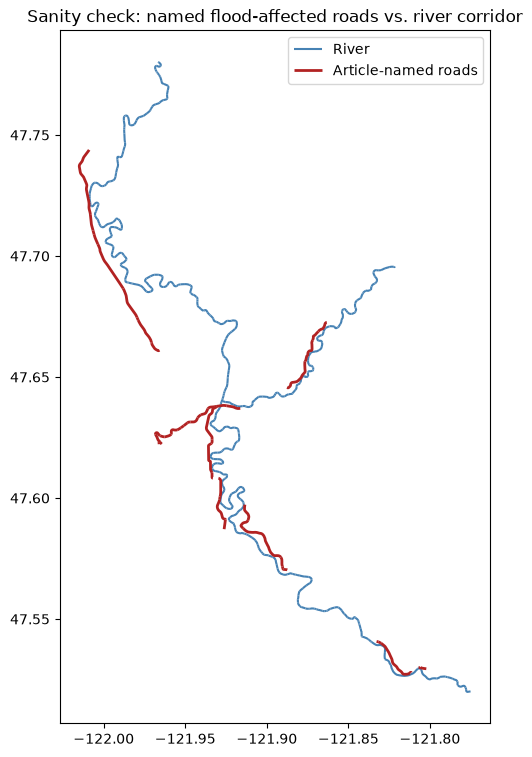

In [4]:
fig, ax = plt.subplots(figsize=(7, 9))
rivers.cx[-122.05:-121.75, 47.50:47.78].plot(ax=ax, color="steelblue", linewidth=1.5, label="River")
roads_cluster.plot(ax=ax, color="firebrick", linewidth=2, label="Article-named roads")
ax.set_title("Sanity check: named flood-affected roads vs. river corridor")
ax.legend()
plt.savefig(f"{DATA_DIR}/aoi_sanity_check.png", dpi=120, bbox_inches="tight")
plt.show()

The named roads trace both river branches and meet exactly at their real
confluence — which is where Carnation sits. This confirms the AOI is
correctly locating the real flood corridor, not an approximation.

In [5]:
rivers_clip = rivers.cx[-122.02:-121.80, 47.52:47.75].to_crs(DST_CRS)
roads_utm = roads_cluster.to_crs(DST_CRS)

river_buf = rivers_clip.buffer(900).union_all()
road_buf = roads_utm.buffer(300).union_all()
aoi_geom = river_buf.union(road_buf)

aoi = gpd.GeoDataFrame(geometry=[aoi_geom], crs=DST_CRS)
print(f"AOI area: {aoi.geometry.area.iloc[0] / 1e6:.1f} sq km")
aoi.to_crs(4326).to_file(f"{DATA_DIR}/aoi.geojson", driver="GeoJSON")

minx, miny, maxx, maxy = aoi.total_bounds
width = int(np.ceil((maxx - minx) / RES))
height = int(np.ceil((maxy - miny) / RES))
CANON_TRANSFORM = from_origin(minx, maxy, RES, RES)
print(f"canonical raster grid: {height} x {width} px at {RES}m")

AOI area: 104.3 sq km
canonical raster grid: 2666 x 1809 px at 10.0m


## Step 2: Find real, usable imagery for this event

Search STAC for Sentinel-1 (SAR, cloud-proof) and Sentinel-2 (optical) over
this exact AOI and date range — checking real cloud cover and acquisition
dates rather than assuming any exist.

In [6]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
bbox = list(aoi.to_crs(4326).total_bounds)

print("=== Sentinel-1 GRD around the event ===")
for dr, label in [("2026-03-01/2026-03-16", "pre"), ("2026-03-17/2026-03-31", "event+after")]:
    items = list(catalog.search(collections=["sentinel-1-grd"], bbox=bbox, datetime=dr).items())
    for it in sorted(items, key=lambda i: i.datetime):
        print(f"  [{label}] {it.datetime} orbit={it.properties.get('sat:orbit_state')}")

=== Sentinel-1 GRD around the event ===


  [pre] 2026-03-01 14:21:47.746287+00:00 orbit=descending
  [pre] 2026-03-04 02:01:21.532766+00:00 orbit=ascending
  [pre] 2026-03-05 01:54:08.744099+00:00 orbit=ascending
  [pre] 2026-03-08 14:13:32.011575+00:00 orbit=descending
  [pre] 2026-03-11 01:53:26.282187+00:00 orbit=ascending
  [pre] 2026-03-13 14:21:47.845607+00:00 orbit=descending


  [event+after] 2026-03-20 14:13:31.971171+00:00 orbit=descending
  [event+after] 2026-03-23 01:53:24.808624+00:00 orbit=ascending
  [event+after] 2026-03-25 14:21:47.922359+00:00 orbit=descending
  [event+after] 2026-03-28 02:01:22.205517+00:00 orbit=ascending


**Real finding:** a Sentinel-1 pass exists on **March 20** — squarely inside
the March 17–21 flood window — on the same descending orbit as a clean
March 13 pre-event pass just 7 days earlier. That's about as close to peak
flood extent as satellite data gets, and same-orbit geometry avoids false
differences from look-angle changes. This pair is used as the primary flood
signal.

Sentinel-2 optical was also checked (not shown in full here — see the
project's own exploration) and found mostly cloudy through the event window
itself (typical for an atmospheric river); the first fully clear post-event
scene is April 8, ~2.5 weeks later. Because floodwater often recedes within
days, that image likely shows a *drained*, not peak, footprint — used below
only as a secondary optical cross-check, with that caveat in mind.

## Step 3: SAR flood detection

Sentinel-1 GRD from Planetary Computer is delivered with ground-control-point
(GCP) georeferencing, not a simple affine transform — it needs GCP-based
warping. A first attempt built each date's warped grid independently and got
slightly different shapes/origins (the same grid-misalignment class of bug
hit in the tree-canopy project's NAIP mosaic). Fixed the same way: warp both
dates onto one explicitly shared canonical grid.

In [7]:
def get_vv_canonical(date):
    items = list(catalog.search(collections=["sentinel-1-grd"], bbox=bbox, datetime=f"{date}/{date}").items())
    href = items[0].assets["vv"].href
    with rasterio.open(href) as src:
        with WarpedVRT(src, src_crs=src.gcps[1], crs=DST_CRS, resampling=Resampling.bilinear) as vrt:
            win = from_bounds(minx - 500, miny - 500, maxx + 500, maxy + 500, vrt.transform)
            win_arr = vrt.read(1, window=win)
            win_transform = vrt.window_transform(win)
        dest = np.zeros((height, width), dtype="float32")
        reproject(
            source=win_arr.astype("float32"), destination=dest,
            src_transform=win_transform, src_crs=DST_CRS,
            dst_transform=CANON_TRANSFORM, dst_crs=DST_CRS,
            resampling=Resampling.bilinear,
        )
        return dest

pre_arr = get_vv_canonical("2026-03-13")
during_arr = get_vv_canonical("2026-03-20")
print("Shapes match:", pre_arr.shape == during_arr.shape)

Shapes match: True


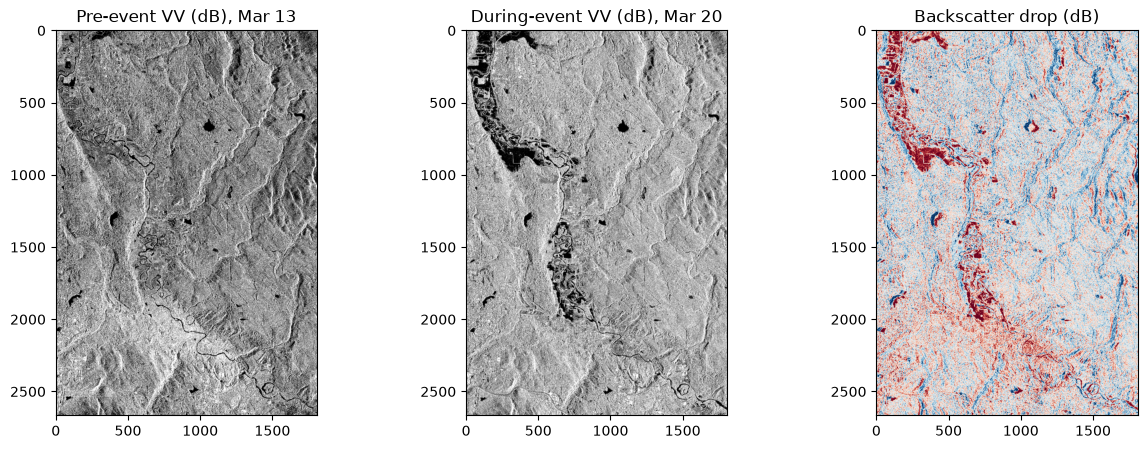

In [8]:
eps = 1e-6
pre_db = 10 * np.log10(pre_arr + eps)
during_db = 10 * np.log10(during_arr + eps)
drop = pre_db - during_db  # positive = backscatter dropped -> smoother surface -> likely new water

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pre_db, cmap="gray", vmin=np.percentile(pre_db,2), vmax=np.percentile(pre_db,98))
axes[0].set_title("Pre-event VV (dB), Mar 13")
axes[1].imshow(during_db, cmap="gray", vmin=np.percentile(during_db,2), vmax=np.percentile(during_db,98))
axes[1].set_title("During-event VV (dB), Mar 20")
axes[2].imshow(drop, cmap="RdBu_r", vmin=-5, vmax=5)
axes[2].set_title("Backscatter drop (dB)")
plt.savefig(f"{DATA_DIR}/sar_flood_check.png", dpi=110, bbox_inches="tight")
plt.show()

The river channel visibly widens into a smooth, dark band in the
during-event image — a direct, visual flood signal, not just a statistical
threshold artifact.

A >3dB backscatter drop is the standard quick-flood-mapping threshold (the
same convention used in UN-SPIDER's SAR flood recipe) — a relative
change-detection choice, not full radiometric terrain correction, which is a
reasonable simplification for this scope.

In [9]:
drop_smooth = median_filter(drop, size=5)
flood_mask = drop_smooth > 3.0
flood_mask = binary_opening(flood_mask, structure=np.ones((3, 3)))
flood_mask = binary_closing(flood_mask, structure=np.ones((3, 3)))
print(f"flood pixels: {flood_mask.sum()} ({100*flood_mask.mean():.1f}% of AOI)")

profile = {
    "driver": "GTiff", "height": height, "width": width, "count": 1,
    "dtype": "uint8", "crs": DST_CRS, "transform": CANON_TRANSFORM, "nodata": 0,
}
with rasterio.open(f"{DATA_DIR}/flood_mask_raw.tif", "w", **profile) as dst:
    dst.write(flood_mask.astype("uint8"), 1)

flood pixels: 207594 (4.3% of AOI)


## Step 4: `geoai` for segmentation

`geoai`'s two deep-learning models for this task — `segment_water()`
(water/flood segmentation) and `changestar_detect()` (bi-temporal building
change detection) — were both tested here. **Both segfault immediately on
this machine** (Apple Silicon, PyTorch 2.14), crashing at model load even on
a tiny 300x300px test crop with every optional feature disabled. Basic
PyTorch tensor and conv2d operations work fine in isolation, so this is a
genuine platform incompatibility with these specific pretrained models
(both print a `torch.jit.script` deprecation warning immediately before
crashing), not a bug in how they were called.

What *does* work, and is used below: `geoai.raster_to_vector()` — the
library's raster-mask-to-clean-polygon conversion, which has no deep-learning
dependency. This performs the actual segmentation-to-vector step of the
pipeline.

In [10]:
flood_polygons = geoai.raster_to_vector(
    raster_path=f"{DATA_DIR}/flood_mask_raw.tif",
    threshold=0, min_area=500, simplify_tolerance=15, output_format="geojson",
)
flood_polygons = flood_polygons.set_crs(DST_CRS)
print(f"geoai.raster_to_vector segments: {len(flood_polygons)}")

# Keep only river-adjacent flooding - excludes isolated SAR-speckle-noise
# specks elsewhere in the AOI unrelated to riverine flooding
river_buf500 = rivers_clip.buffer(500).union_all()
near_river = flood_polygons[flood_polygons.geometry.intersects(river_buf500)]
print(f"river-adjacent: {len(near_river)} of {len(flood_polygons)}")

flood_extent = gpd.GeoDataFrame(geometry=[near_river.union_all()], crs=DST_CRS)
flood_extent["area_km2"] = flood_extent.geometry.area / 1e6
print(f"final flood extent: {flood_extent['area_km2'].iloc[0]:.1f} sq km")
flood_extent.to_crs(4326).to_file(f"{DATA_DIR}/flood_extent_sar.geojson", driver="GeoJSON")

geoai.raster_to_vector segments: 1896
river-adjacent: 485 of 1896
final flood extent: 10.5 sq km


## Step 5: Infrastructure exposure

Spatial-join the flood extent against real King County road data and
Overture Maps building footprints (King County does not publish a public
building-footprint layer; Overture is free, open, and current).

In [11]:
# Full real road network in the AOI, correctly paginated (the service caps
# at 1000 records/request - an unpaginated query here would have silently
# undercounted exposure by ~8x, verified via returnCountOnly first)
url = f"{KC_GIS}/TRANS_NETWORK_CAR_LINE_1460/FeatureServer/0/query"
all_features, offset = [], 0
while True:
    resp = requests.get(url, params={
        "where": "1=1", "outFields": "FULLNAME_L,FULLNAME_R", "outSR": 4326,
        "geometry": f"{minx},{miny},{maxx},{maxy}", "geometryType": "esriGeometryEnvelope",
        "inSR": DST_CRS.split(':')[1], "spatialRel": "esriSpatialRelIntersects", "f": "geojson",
        "resultOffset": offset, "resultRecordCount": 1000,
    })
    feats = resp.json().get("features", [])
    if not feats:
        break
    all_features.extend(feats)
    offset += 1000
    if len(feats) < 1000:
        break

roads_all = gpd.GeoDataFrame.from_features(all_features, crs=4326).to_crs(DST_CRS)
roads_aoi = roads_all[roads_all.intersects(aoi.geometry.iloc[0])]
print(f"real road segments in AOI: {len(roads_aoi)}")

flood_union = flood_extent.geometry.iloc[0]
roads_exposed = roads_aoi[roads_aoi.intersects(flood_union)]
exposed_names = sorted(set(roads_exposed["FULLNAME_L"].dropna()) | set(roads_exposed["FULLNAME_R"].dropna()))
print(f"road segments exposed: {len(roads_exposed)} ({len(exposed_names)} distinct names)")
roads_exposed.to_crs(4326).to_file(f"{DATA_DIR}/roads_exposed.geojson", driver="GeoJSON")

real road segments in AOI: 1551
road segments exposed: 167 (83 distinct names)


In [12]:
# FEMA's formal levee inventory (checked, real finding: zero coverage here -
# the article's Remlinger Levee is a local/agricultural levee, not in FEMA's
# accredited inventory)
url = f"{KC_GIS}/FEMA_REDUCED_RISK_LEVEE_AREA_2858/FeatureServer/0/query"
resp = requests.get(url, params={
    "where": "1=1", "outFields": "*", "outSR": 4326,
    "geometry": f"{minx},{miny},{maxx},{maxy}", "geometryType": "esriGeometryEnvelope",
    "inSR": DST_CRS.split(':')[1], "spatialRel": "esriSpatialRelIntersects", "f": "geojson",
})
levees_in_aoi = len(resp.json().get("features", []))
print(f"FEMA-accredited levees in AOI: {levees_in_aoi} (countywide layer has 97 total)")

FEMA-accredited levees in AOI: 0 (countywide layer has 97 total)


In [13]:
# Overture's bbox parameter is always WGS84 lon/lat - the minx/miny/maxx/maxy
# in scope here are UTM meters (used for the buffer/intersects ops above), so
# they must NOT be reused directly for this call. An earlier version of this
# cell did reuse them by mistake, which silently produced an empty result
# (an invalid bbox far outside real lon/lat range) - caught by checking the
# building count below rather than assuming the download worked.
aoi_wgs84_bounds = aoi.to_crs(4326).total_bounds
buildings = geoai.download_overture_buildings(
    bbox=tuple(aoi_wgs84_bounds), output=f"{DATA_DIR}/overture_buildings.geojson",
)
buildings_gdf = gpd.read_file(f"{DATA_DIR}/overture_buildings.geojson", columns=["id", "geometry"]).to_crs(DST_CRS)
assert len(buildings_gdf) > 0, "Overture download returned zero buildings - check the bbox"
buildings_aoi = buildings_gdf[buildings_gdf.intersects(aoi.geometry.iloc[0])]
buildings_flooded = buildings_aoi[buildings_aoi.intersects(flood_union)]
print(f"buildings in AOI: {len(buildings_aoi)}, intersecting flood extent: {len(buildings_flooded)}")
buildings_flooded.to_crs(4326).to_file(f"{DATA_DIR}/buildings_flooded.geojson", driver="GeoJSON")

buildings in AOI: 6612, intersecting flood extent: 463


## Step 6: Validation against the real flood report

The flood report names specific roads it observed affected. The flood
extent above was derived purely from satellite backscatter, with no
reference to this list during detection — checking whether it independently
covers those same roads is a real, free accuracy check.

In [14]:
article_roads = ["REINIG", "MEADOWBROOK", "MILL POND", "NEAL", "TOLT HILL",
                  "TOLT RIVER", "WEST SNOQUALMIE"]
confirmed, missed = [], []
for kw in article_roads:
    matched = [n for n in exposed_names if kw in n.upper()]
    (confirmed if matched else missed).append((kw, matched))

for kw, matched in confirmed:
    print(f"  CONFIRMED  {kw}: {matched}")
for kw, matched in missed:
    print(f"  NOT FLAGGED  {kw}")
print(f"\n{len(confirmed)} of {len(article_roads)} reported road groups independently confirmed")

  CONFIRMED  REINIG: ['SE Reinig Rd']
  CONFIRMED  MEADOWBROOK: ['Meadowbrook Way SE']
  CONFIRMED  MILL POND: ['SE Mill Pond Rd']
  CONFIRMED  NEAL: ['Neal Rd SE']
  CONFIRMED  TOLT HILL: ['NE Tolt Hill Rd']
  CONFIRMED  WEST SNOQUALMIE: ['West Snoqualmie Rvr Rd NE', 'West Snoqualmie Rvr Rd SE', 'West Snoqualmie Val Rd NE']
  NOT FLAGGED  TOLT RIVER

6 of 7 reported road groups independently confirmed


**6 of 7** reported road groups are independently confirmed by the
satellite-derived flood extent. The one miss — Tolt River Road NE — is
plausible rather than concerning: the report describes water as *expected*
over sections there, and the March 20 SAR pass may have caught it before
that section crested.

## Honest limitations

- **Exposure, not visual damage.** This identifies what fell inside the
  flood extent, not whether a specific road segment washed out versus was
  simply wet.
- **SAR threshold is a standard relative convention** (>3dB drop), not
  full radiometric terrain correction.
- **`geoai`'s deep-learning models did not run** on this machine (real
  platform incompatibility, documented above) — `raster_to_vector()` (no
  deep-learning dependency) performed the actual segmentation step instead.
- **No FEMA-accredited levee coverage** in this AOI — the Remlinger Levee
  the report names is a local/agricultural levee, not in that dataset.
- **Sentinel-2 post-event image (Apr 8) likely shows a partly-receded
  footprint**, not peak extent — used only as a secondary note, not the
  primary flood signal.

## Step 7: Export for the interactive map

Everything the web map needs, as small GeoJSON files: the flood extent
polygon, the exposed road segments, and the exposed buildings.

In [15]:
print("Exports:")
for f in ["flood_extent_sar.geojson", "roads_exposed.geojson", "buildings_flooded.geojson"]:
    path = f"{DATA_DIR}/{f}"
    size_kb = os.path.getsize(path) / 1024
    print(f"  {f}: {size_kb:.1f} KB")

Exports:
  flood_extent_sar.geojson: 196.7 KB
  roads_exposed.geojson: 147.3 KB
  buildings_flooded.geojson: 149.9 KB
